## Step 1: Load dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("LargeMovieDataset.csv")
df

,MovieID,Title,Genre,Rating,Popularity
0,1,Chaos Theory 1,Horror,3.5,93
1,2,Mystic Falls 2,Sci-Fi,3.4,34
2,3,The Legend 3,Horror,4.2,74
3,4,Chaos Theory 4,Documentary,2.2,59
4,5,Infinite Horizon 5,Sci-Fi,3.7,77
...,...,...,...,...,...
9995,9996,Mystic Falls 9996,Horror,4.7,30
9996,9997,Chaos Theory 9997,Sci-Fi,4.3,76
9997,9998,Storm Riders 9998,Fantasy,3.7,77
9998,9999,Fearless Fighter 9999,Comedy,4.2,34


In [3]:
df.head()

,MovieID,Title,Genre,Rating,Popularity
0,1,Chaos Theory 1,Horror,3.5,93
1,2,Mystic Falls 2,Sci-Fi,3.4,34
2,3,The Legend 3,Horror,4.2,74
3,4,Chaos Theory 4,Documentary,2.2,59
4,5,Infinite Horizon 5,Sci-Fi,3.7,77


In [4]:
df.tail()

,MovieID,Title,Genre,Rating,Popularity
9995,9996,Mystic Falls 9996,Horror,4.7,30
9996,9997,Chaos Theory 9997,Sci-Fi,4.3,76
9997,9998,Storm Riders 9998,Fantasy,3.7,77
9998,9999,Fearless Fighter 9999,Comedy,4.2,34
9999,10000,Mystic Falls 10000,Sci-Fi,4.1,11


In [5]:
df.shape

(10000, 5)

In [6]:
df.columns

Index(['MovieID', 'Title', 'Genre', 'Rating', 'Popularity'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MovieID     10000 non-null  int64  
 1   Title       10000 non-null  object 
 2   Genre       10000 non-null  object 
 3   Rating      10000 non-null  float64
 4   Popularity  10000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 390.8+ KB


In [8]:
df.describe()

,MovieID,Rating,Popularity
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,3.006050,50.729500
std,2886.89568,1.148119,28.636573
min,1.00000,1.000000,1.000000
25%,2500.75000,2.000000,26.000000
50%,5000.50000,3.000000,51.000000
75%,7500.25000,4.000000,76.000000
max,10000.00000,5.000000,100.000000


In [9]:
df.describe(include="object")

,Title,Genre
count,10000,10000
unique,10000,10
top,Chaos Theory 1,Horror
freq,1,1052


In [10]:
df.isnull().sum()

MovieID       0
Title         0
Genre         0
Rating        0
Popularity    0
dtype: int64

## Step 2: Encode the data (One-hot encoder) (Only for genre column)

In [11]:
from sklearn.preprocessing import OneHotEncoder

In [12]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[['Genre']])
encoded_columns = pd.DataFrame(one_hot_encoded, columns = encoder.get_feature_names_out(['Genre']))
df_encoded = pd.concat([df,encoded_columns], axis = 1).drop(columns = ['Genre', 'Title'])
df_encoded.head()

,MovieID,Rating,Popularity,Genre_Action,Genre_Adventure,Genre_Comedy,Genre_Documentary,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Romance,Genre_Sci-Fi,Genre_Thriller
0,1,3.5,93,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,3.4,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3,4.2,74,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,4,2.2,59,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,3.7,77,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Step 3: Scale the entire dataset with standard scaling

In [13]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [14]:
scaled_data = scaler.fit_transform(df_encoded)
scaled_data = pd.DataFrame(scaled_data, columns=df_encoded.columns)
scaled_data.head()

,MovieID,Rating,Popularity,Genre_Action,Genre_Adventure,Genre_Comedy,Genre_Documentary,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Romance,Genre_Sci-Fi,Genre_Thriller
0,-1.731878,0.430247,1.476176,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,2.916454,-0.333518,-0.329244,-0.337025
1,-1.731531,0.343143,-0.584230,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,-0.342882,-0.333518,3.037260,-0.337025
2,-1.731185,1.039970,0.812655,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,2.916454,-0.333518,-0.329244,-0.337025
3,-1.730838,-0.702096,0.288823,-0.329244,-0.334628,-0.327188,2.986743,-0.327001,-0.337576,-0.342882,-0.333518,-0.329244,-0.337025
4,-1.730492,0.604453,0.917422,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,-0.342882,-0.333518,3.037260,-0.337025


In [15]:
scaled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MovieID            10000 non-null  float64
 1   Rating             10000 non-null  float64
 2   Popularity         10000 non-null  float64
 3   Genre_Action       10000 non-null  float64
 4   Genre_Adventure    10000 non-null  float64
 5   Genre_Comedy       10000 non-null  float64
 6   Genre_Documentary  10000 non-null  float64
 7   Genre_Drama        10000 non-null  float64
 8   Genre_Fantasy      10000 non-null  float64
 9   Genre_Horror       10000 non-null  float64
 10  Genre_Romance      10000 non-null  float64
 11  Genre_Sci-Fi       10000 non-null  float64
 12  Genre_Thriller     10000 non-null  float64
dtypes: float64(13)
memory usage: 1015.8 KB


# Kmeans Clustering 

In [16]:
from sklearn.cluster import KMeans

In [17]:
# pip install --upgrade scikit-learn threadpoolctl numpy

In [18]:
# pip install threadpoolctl==3.1.0

## Step 4: Find optimal number of clusters.

In [19]:
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

C:\Users\nensi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\nensi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\nensi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\nensi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\nensi\anaconda3\lib\site-packages\sklearn\clust

In [20]:
wcss

[130000.00000000004,
 118877.5968472749,
 107741.7889258356,
 96620.53547583138,
 85501.70731267477,
 74393.50200938697,
 63235.18656244599,
 52187.145004244536,
 41056.04097265644]

## Step 5: Plot the graph of wcss as 'y' and range(1,5) as 'x'.

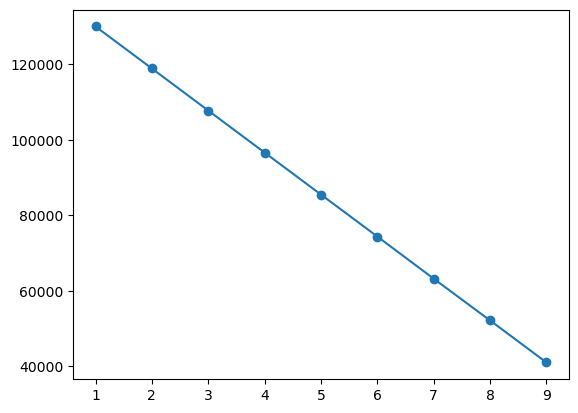

In [21]:
plt.plot(range(1,10), wcss, marker='o')

## Step 6: Apply k means cluster model with optimal number on dataset

In [22]:
kmeans = KMeans(n_clusters=10, init='k-means++', random_state=42)
scaled_data['Cluster'] = kmeans.fit_predict(scaled_data)

C:\Users\nensi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [23]:
scaled_data.head()

,MovieID,Rating,Popularity,Genre_Action,Genre_Adventure,Genre_Comedy,Genre_Documentary,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Romance,Genre_Sci-Fi,Genre_Thriller,Cluster
0,-1.731878,0.430247,1.476176,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,2.916454,-0.333518,-0.329244,-0.337025,2
1,-1.731531,0.343143,-0.584230,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,-0.342882,-0.333518,3.037260,-0.337025,6
2,-1.731185,1.039970,0.812655,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,2.916454,-0.333518,-0.329244,-0.337025,2
3,-1.730838,-0.702096,0.288823,-0.329244,-0.334628,-0.327188,2.986743,-0.327001,-0.337576,-0.342882,-0.333518,-0.329244,-0.337025,4
4,-1.730492,0.604453,0.917422,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,-0.342882,-0.333518,3.037260,-0.337025,6


In [24]:
scaled_data['Title'] = df['Title'].values

In [25]:
scaled_data.head()

,MovieID,Rating,Popularity,Genre_Action,Genre_Adventure,Genre_Comedy,Genre_Documentary,Genre_Drama,Genre_Fantasy,Genre_Horror,Genre_Romance,Genre_Sci-Fi,Genre_Thriller,Cluster,Title
0,-1.731878,0.430247,1.476176,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,2.916454,-0.333518,-0.329244,-0.337025,2,Chaos Theory 1
1,-1.731531,0.343143,-0.584230,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,-0.342882,-0.333518,3.037260,-0.337025,6,Mystic Falls 2
2,-1.731185,1.039970,0.812655,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,2.916454,-0.333518,-0.329244,-0.337025,2,The Legend 3
3,-1.730838,-0.702096,0.288823,-0.329244,-0.334628,-0.327188,2.986743,-0.327001,-0.337576,-0.342882,-0.333518,-0.329244,-0.337025,4,Chaos Theory 4
4,-1.730492,0.604453,0.917422,-0.329244,-0.334628,-0.327188,-0.334813,-0.327001,-0.337576,-0.342882,-0.333518,3.037260,-0.337025,6,Infinite Horizon 5


## Step 7: Create a function that will take anyone value of movie from user and it will recommend the similar movies to the user. For example if any action movie is provided as a input from user then that movie's cluster will be checked in dataset and out of that cluster few movies will be recommended to user.

In [26]:
def recommend_movies(movie_title, data_with_clusters, num_recommendations=5):
    try:
        movie_cluster = data_with_clusters.loc[data_with_clusters['Title'] == movie_title, 'Cluster'].values[0]

        similar_movies = data_with_clusters[
            (data_with_clusters['Cluster'] == movie_cluster) & (data_with_clusters['Title'] != movie_title)
        ]

        recommendations = similar_movies['Title'].head(num_recommendations).tolist()

        if not recommendations:
            return ["No similar movies found in this cluster."]

        return recommendations
    except IndexError:
        return ["Movie not found in the dataset."]

In [28]:
print(recommend_movies('Mystic Falls 2', scaled_data))

['Infinite Horizon 5', 'Final Stand 10', 'Breaking Point 38', 'Eternal Love 39', 'Eternal Love 41']


## Flask App

In [29]:
pip install flask

Note: you may need to restart the kernel to use updated packages.
